# Week-6

In [1]:
import re
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

# -----------------------------
# 1) Set input ZIP path
# -----------------------------
ZIP_PATH = Path("../../../data/raw/Hengill Food Web fluxes/Hengill Food Web fluxes.zip")  # <-- edit

In [2]:
# -----------------------------
# Helpers
# -----------------------------
KIND_MAP = {
    "Complete": "communities_energy flux_Complete Food Web",
    "Core": "communities_energy flux_Core Food Web",
}

FLUX_COLS = ["flux.mte", "flux.mte.2", "flux.new", "flux.new.2"]

def _read_csv_from_zip(zf: zipfile.ZipFile, member: str) -> pd.DataFrame:
    with zf.open(member) as f:
        return pd.read_csv(f)

def _find_member(zf: zipfile.ZipFile, pattern: str) -> str | None:
    pat = re.compile(pattern)
    for name in zf.namelist():
        if pat.search(name):
            return name
    return None

def _list_is_ids(zf: zipfile.ZipFile, base_folder: str) -> list[str]:
    # Looks for ".../IS{digits}/nodes.csv"
    pat = re.compile(re.escape(base_folder) + r"/IS(\d+)/nodes\.csv$")
    ids = set()
    for name in zf.namelist():
        m = pat.search(name)
        if m:
            ids.add(m.group(1))
    return sorted(ids, key=lambda x: int(x))

def _safe_float_series(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")

def _flux_stats(df_links: pd.DataFrame, col: str, prefix: str) -> dict:
    if col not in df_links.columns:
        return {}
    s = _safe_float_series(df_links[col]).dropna()
    if s.empty:
        return {f"{prefix}{col}.n": 0}

    desc = s.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    out = {
        f"{prefix}{col}.n": int(desc["count"]),
        f"{prefix}{col}.sum": float(s.sum()),
        f"{prefix}{col}.mean": float(desc["mean"]),
        f"{prefix}{col}.std": float(desc["std"]) if not np.isnan(desc["std"]) else np.nan,
        f"{prefix}{col}.min": float(desc["min"]),
        f"{prefix}{col}.p05": float(desc["5%"]),
        f"{prefix}{col}.p25": float(desc["25%"]),
        f"{prefix}{col}.median": float(desc["50%"]),
        f"{prefix}{col}.p75": float(desc["75%"]),
        f"{prefix}{col}.p95": float(desc["95%"]),
        f"{prefix}{col}.max": float(desc["max"]),
    }
    return out

def build_hengill_eda_summary(zip_path: Path) -> pd.DataFrame:
    rows: list[dict] = []

    with zipfile.ZipFile(zip_path, "r") as zf:
        # Optional "control panel" totals file (if present)
        cp_member = _find_member(zf, r"(^|/)(flux_foodweb_cp\.csv)$")
        df_cp = None
        if cp_member:
            df_cp = _read_csv_from_zip(zf, cp_member)
            # normalize likely columns
            df_cp.columns = [c.strip() for c in df_cp.columns]

        for kind, base_folder in KIND_MAP.items():
            is_ids = _list_is_ids(zf, base_folder)

            for is_id in is_ids:
                base = f"{base_folder}/IS{is_id}/"
                nodes_path = base + "nodes.csv"
                links_path = base + "trophic.links.csv"
                props_path = base + "properties.csv"

                nodes = _read_csv_from_zip(zf, nodes_path)
                links = _read_csv_from_zip(zf, links_path)

                row = {
                    "zip_file": zip_path.name,
                    "kind": kind,
                    "stream_id": f"IS{is_id}",
                    "nodes_path": nodes_path,
                    "links_path": links_path,
                }

                # Basic counts
                S = int(len(nodes))
                L = int(len(links))
                row["S"] = S
                row["L"] = L
                row["connectance_L_over_S2"] = float(L / (S * S)) if S > 0 else np.nan
                row["connectance_L_over_S(S-1)"] = float(L / (S * (S - 1))) if S > 1 else np.nan

                # Sanity checks (optional but useful to report)
                for required in ["consumer", "resource"]:
                    row[f"has_{required}_col"] = required in links.columns

                if "consumer" in links.columns and "resource" in links.columns:
                    row["n_self_loops"] = int((links["consumer"] == links["resource"]).sum())
                    row["n_duplicate_pairs"] = int(links.duplicated(subset=["consumer", "resource"]).sum())
                else:
                    row["n_self_loops"] = np.nan
                    row["n_duplicate_pairs"] = np.nan

                # Properties (temperature etc.) if available
                try:
                    props = _read_csv_from_zip(zf, props_path)
                    row["properties_path"] = props_path
                    # Add a few commonly present columns if they exist
                    for c in ["TS", "TL", "temperature", "temp"]:
                        if c in props.columns:
                            row[f"props_{c}"] = props.loc[0, c]
                except KeyError:
                    row["properties_path"] = None

                # Flux summaries
                for col in FLUX_COLS:
                    row.update(_flux_stats(links, col, prefix=""))

                # Ratios (when possible)
                if "flux.mte" in links.columns and "flux.new" in links.columns:
                    mte_sum = _safe_float_series(links["flux.mte"]).sum()
                    new_sum = _safe_float_series(links["flux.new"]).sum()
                    row["ratio_flux.new_over_flux.mte"] = float(new_sum / mte_sum) if mte_sum else np.nan

                if "flux.mte" in links.columns and "flux.mte.2" in links.columns:
                    mte_sum = _safe_float_series(links["flux.mte"]).sum()
                    mte2_sum = _safe_float_series(links["flux.mte.2"]).sum()
                    row["ratio_flux.mte.2_over_flux.mte"] = float(mte2_sum / mte_sum) if mte_sum else np.nan

                # Merge in cp totals if the file exists and looks matchable
                if df_cp is not None:
                    # Try to find plausible key columns
                    cols_lower = {c.lower(): c for c in df_cp.columns}
                    # candidates: stream/site column
                    stream_col = None
                    for cand in ["site", "stream", "is", "id", "stream_id"]:
                        if cand in cols_lower:
                            stream_col = cols_lower[cand]
                            break
                    kind_col = None
                    for cand in ["kind", "type", "web", "web_type", "network"]:
                        if cand in cols_lower:
                            kind_col = cols_lower[cand]
                            break

                    if stream_col:
                        stream_val = f"IS{is_id}"
                        mask = df_cp[stream_col].astype(str).str.strip().str.upper().eq(stream_val.upper())
                        if kind_col:
                            mask2 = df_cp[kind_col].astype(str).str.strip().str.lower().str.contains(kind.lower())
                            mask = mask & mask2

                        hit = df_cp.loc[mask]
                        if len(hit) >= 1:
                            hit0 = hit.iloc[0]
                            # Bring over the most relevant cp totals if present
                            for c in ["flux.mte", "flux.new", "S", "L", "TS", "TL"]:
                                if c in df_cp.columns:
                                    row[f"cp_{c}"] = hit0[c]

                            # Check total consistency for flux.mte if both exist
                            if "cp_flux.mte" in row and "flux.mte.sum" in row:
                                try:
                                    row["check_flux.mte_sum_minus_cp"] = float(row["flux.mte.sum"] - float(row["cp_flux.mte"]))
                                except Exception:
                                    row["check_flux.mte_sum_minus_cp"] = np.nan

                rows.append(row)

    return pd.DataFrame(rows)

In [3]:
# -----------------------------
# 2) Run and save
# -----------------------------
df_summary = build_hengill_eda_summary(ZIP_PATH)

out_csv = Path("hengill_foodweb_eda_summary.csv")
df_summary.to_csv(out_csv, index=False)

display(df_summary.head(10))
print(f"Saved: {out_csv.resolve()}")

,zip_file,kind,stream_id,nodes_path,links_path,S,L,connectance_L_over_S2,connectance_L_over_S(S-1),has_consumer_col,...,flux.new.2.std,flux.new.2.min,flux.new.2.p05,flux.new.2.p25,flux.new.2.median,flux.new.2.p75,flux.new.2.p95,flux.new.2.max,ratio_flux.new_over_flux.mte,ratio_flux.mte.2_over_flux.mte
0,Hengill Food Web fluxes.zip,Complete,IS1,communities_energy flux_Complete Food Web/IS1/...,communities_energy flux_Complete Food Web/IS1/...,37,223,0.162893,0.167417,True,...,0.008776,1.009514e-08,2.827573e-07,1.671042e-05,0.000120,0.000798,0.009059,0.118135,1.021597,1.202943
1,Hengill Food Web fluxes.zip,Complete,IS3,communities_energy flux_Complete Food Web/IS3/...,communities_energy flux_Complete Food Web/IS3/...,36,231,0.178241,0.183333,True,...,0.013444,2.568214e-08,1.328967e-06,2.207761e-05,0.000249,0.002253,0.016845,0.123595,1.154060,1.201454
2,Hengill Food Web fluxes.zip,Complete,IS4,communities_energy flux_Complete Food Web/IS4/...,communities_energy flux_Complete Food Web/IS4/...,41,319,0.189768,0.194512,True,...,0.000369,5.023203e-09,8.419593e-08,1.451336e-06,0.000011,0.000057,0.000862,0.002870,0.971156,1.218815
3,Hengill Food Web fluxes.zip,Complete,IS5,communities_energy flux_Complete Food Web/IS5/...,communities_energy flux_Complete Food Web/IS5/...,43,281,0.151974,0.155592,True,...,0.010146,1.002328e-08,3.018508e-07,4.664845e-06,0.000062,0.000372,0.007054,0.141807,1.113789,1.205056
4,Hengill Food Web fluxes.zip,Complete,IS6,communities_energy flux_Complete Food Web/IS6/...,communities_energy flux_Complete Food Web/IS6/...,37,249,0.181885,0.186937,True,...,0.015098,9.589380e-09,3.285067e-08,3.078107e-06,0.000078,0.000892,0.010481,0.158747,1.110758,1.205514
5,Hengill Food Web fluxes.zip,Complete,IS7,communities_energy flux_Complete Food Web/IS7/...,communities_energy flux_Complete Food Web/IS7/...,40,329,0.205625,0.210897,True,...,0.000513,1.286856e-10,1.726212e-08,3.437857e-07,0.000003,0.000027,0.000526,0.004274,1.008556,1.226588
6,Hengill Food Web fluxes.zip,Complete,IS8,communities_energy flux_Complete Food Web/IS8/...,communities_energy flux_Complete Food Web/IS8/...,33,173,0.158861,0.163826,True,...,0.045423,2.415077e-07,1.474999e-06,2.695672e-05,0.000174,0.001377,0.011157,0.540970,1.274991,1.200128
7,Hengill Food Web fluxes.zip,Complete,IS9,communities_energy flux_Complete Food Web/IS9/...,communities_energy flux_Complete Food Web/IS9/...,39,293,0.192636,0.197706,True,...,0.006608,6.185677e-09,9.917120e-08,1.447608e-06,0.000008,0.000089,0.001830,0.095518,1.012506,1.210016
8,Hengill Food Web fluxes.zip,Complete,IS10,communities_energy flux_Complete Food Web/IS10...,communities_energy flux_Complete Food Web/IS10...,33,243,0.223140,0.230114,True,...,0.000300,1.165813e-10,2.270448e-09,1.277010e-07,0.000002,0.000019,0.000476,0.002602,1.047511,1.232194
9,Hengill Food Web fluxes.zip,Complete,IS11,communities_energy flux_Complete Food Web/IS11...,communities_energy flux_Complete Food Web/IS11...,41,280,0.166568,0.170732,True,...,0.000705,2.549589e-08,1.751225e-07,1.459746e-06,0.000006,0.000045,0.000688,0.008996,0.981946,1.218646


Saved: /Users/jorge/Developer/qmul-phd-framework/docs/progress_notebooks_logs/2026/hengill_foodweb_eda_summary.csv


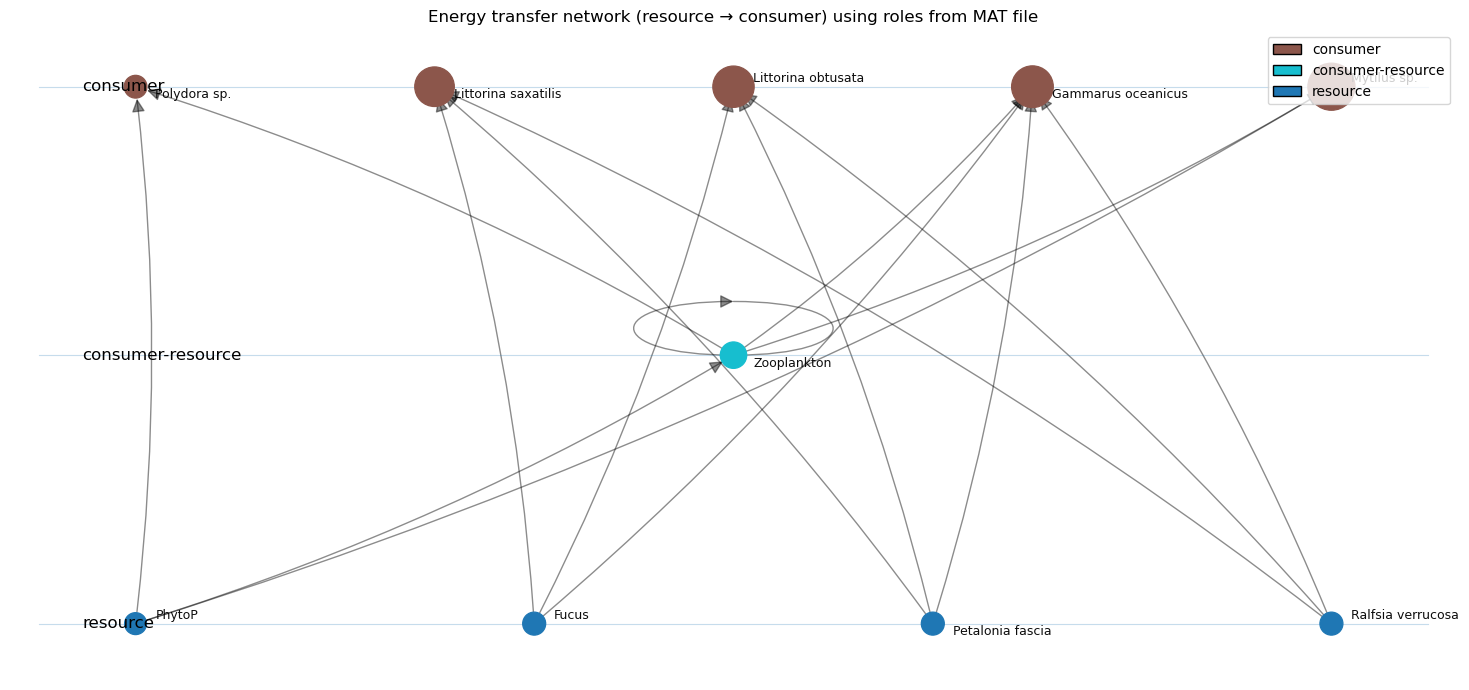

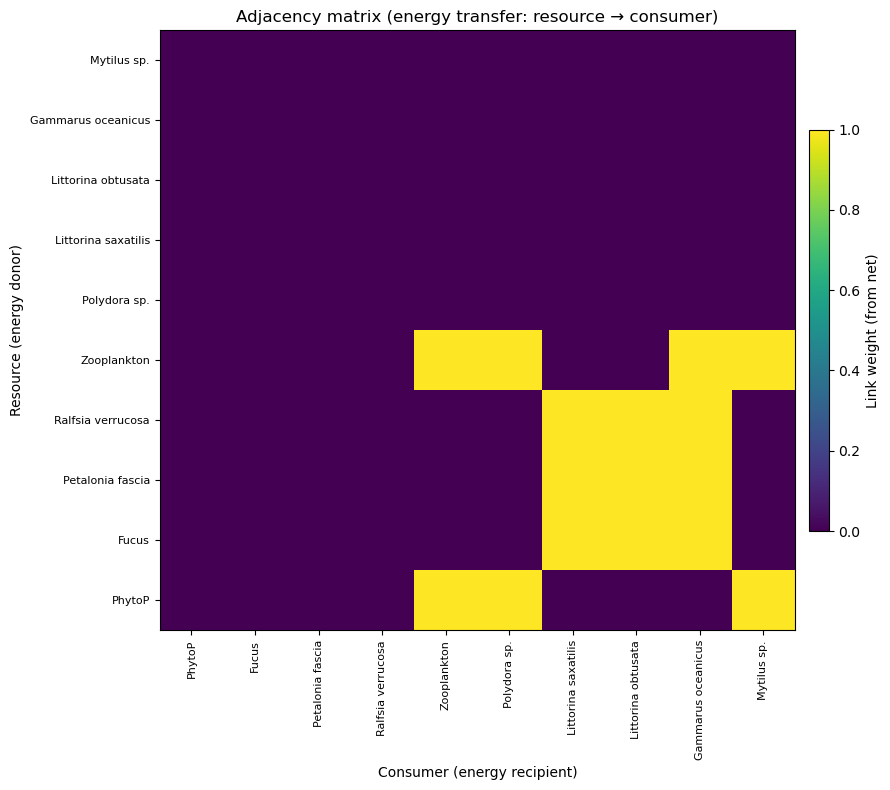

,node_id,taxonomy,mass,role,in_deg_energy,out_deg_energy
0,7,Polydora sp.,0.000200,consumer,2,0
1,3,Littorina saxatilis,0.082900,consumer,3,0
2,2,Littorina obtusata,0.147200,consumer,3,0
3,1,Gammarus oceanicus,0.166500,consumer,4,0
4,4,Mytilus sp.,0.987700,consumer,2,0
5,9,Zooplankton,0.001000,consumer-resource,2,4
6,6,PhytoP,0.000100,resource,0,3
7,0,Fucus,0.000228,resource,0,3
8,5,Petalonia fascia,0.000228,resource,0,3
9,8,Ralfsia verrucosa,0.000228,resource,0,3


In [13]:
import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# Config
# -----------------------------
MAT_PATH = "../../../src/matlab/data/foodwebs_mat/SF1M2_tax_mass.mat"
EDGE_ALPHA = 0.45
ARROW_SIZE = 20

# Role rows (top -> bottom)
Y_LEVELS = {
    "consumer": 2.0,
    "consumer-resource": 1.0,
    "resource": 0.0,
}

# Control label density
MAX_LABELS = 60
LABEL_FONTSIZE = 9

# -----------------------------
# Helpers
# -----------------------------
def _to_str(x) -> str:
    """Robust conversion from MATLAB-loaded types to clean Python strings."""
    if x is None:
        return ""
    if isinstance(x, bytes):
        return x.decode("utf-8", errors="ignore").strip()
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return ""
        return _to_str(x.item())
    return str(x).strip()

def _canon_role(s: str) -> str:
    s = _to_str(s).lower().strip()
    s = s.replace("_", "-").replace(" ", "-")
    if s in {"consumer", "predator", "apex", "apex-predator"}:
        return "consumer"
    if s in {"resource", "prey", "basal", "basal-resource"}:
        return "resource"
    if s in {"consumer-resource", "predator-prey", "intermediate"}:
        return "consumer-resource"
    return "consumer-resource"

# -----------------------------
# Load .mat
# -----------------------------
data = sio.loadmat(MAT_PATH, squeeze_me=True, struct_as_record=False)

net = data.get("net", None)
if net is None:
    raise KeyError("Variable 'net' not found in the .mat file.")

A = net.tocsr() if sp.issparse(net) else sp.csr_matrix(np.asarray(net))
n = A.shape[0]

taxonomy = data.get("taxonomy", None)
taxonomy = (
    np.asarray(taxonomy).reshape(-1).astype(object)
    if taxonomy is not None
    else np.array([f"sp_{i+1}" for i in range(n)], dtype=object)
)
taxonomy = np.array([_to_str(x) for x in taxonomy], dtype=object)

mass = data.get("mass", None)
mass = np.asarray(mass, dtype=float).reshape(-1) if mass is not None else np.ones(n, dtype=float)

role = data.get("role", None)
role = np.asarray(role).reshape(-1).astype(object) if role is not None else None
role = np.array([_canon_role(x) for x in role], dtype=object) if role is not None else None

# -----------------------------
# IMPORTANT FIX:
# Use ROLE from the MAT file for vertical bands (no degree-derived inference).
# Also: treat the matrix as ENERGY direction: resource -> consumer
# (This matches your role check: basal resources have outgoing edges.)
# -----------------------------
if role is None:
    raise ValueError("role variable is missing in the .mat file; cannot build 3-row layout from role.")

row_class = {i: role[i] for i in range(n)}  # consumer / consumer-resource / resource

# -----------------------------
# Build ENERGY graph directly from A
# energy direction: resource i -> consumer j  (use A[i, j] as-is)
# -----------------------------
G_energy = nx.DiGraph()
for i in range(n):
    G_energy.add_node(
        i,
        taxonomy=taxonomy[i],
        mass=float(mass[i]),
        role=row_class[i],
    )

rows, cols = A.nonzero()
for i, j in zip(rows.tolist(), cols.tolist()):
    G_energy.add_edge(i, j, weight=float(A[i, j]))

# -----------------------------
# Layout: 3 horizontal bands + mass ordering within each band
# -----------------------------
pos = {}
for cls, y in Y_LEVELS.items():
    nodes_cls = [i for i in range(n) if row_class[i] == cls]
    if not nodes_cls:
        continue

    nodes_sorted = sorted(nodes_cls, key=lambda i: mass[i])  # small -> large within band
    xs = np.linspace(0.05, 0.95, len(nodes_sorted)) if len(nodes_sorted) > 1 else np.array([0.5])

    for k, i in enumerate(nodes_sorted):
        pos[i] = (float(xs[k]), float(y))

# safety
for i in range(n):
    if i not in pos:
        pos[i] = (0.5, Y_LEVELS["consumer-resource"])

# -----------------------------
# Node sizes (by mass)
# -----------------------------
m = np.clip(mass, 1e-12, None)
lm = np.log10(m)
lm_scaled = (lm - np.nanmin(lm)) / (np.nanmax(lm) - np.nanmin(lm)) if np.nanmax(lm) > np.nanmin(lm) else np.zeros_like(lm)
node_sizes = 250 + 900 * (lm_scaled ** 1.5)

# -----------------------------
# Colors by role (use legend, not numeric colorbar)
# -----------------------------
role_palette = {
    "resource": "#1f77b4",
    "consumer-resource": "#17becf",
    "consumer": "#8c564b",
}
node_colors = [role_palette.get(row_class[i], "#7f7f7f") for i in range(n)]

# -----------------------------
# Plot 1: ENERGY network (resource -> consumer)
# -----------------------------
fig, ax = plt.subplots(figsize=(15, 7))
ax.set_title("Energy transfer network (resource → consumer) using roles from MAT file")
ax.axis("off")

for cls, y in Y_LEVELS.items():
    ax.axhline(y=y, xmin=0.02, xmax=0.98, linewidth=0.8, alpha=0.25)
    ax.text(0.01, y, cls, va="center", ha="left", fontsize=12)

nx.draw_networkx_edges(
    G_energy,
    pos,
    ax=ax,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=ARROW_SIZE,
    width=1.0,
    alpha=EDGE_ALPHA,
    connectionstyle="arc3,rad=0.06",
)

nx.draw_networkx_nodes(
    G_energy,
    pos,
    ax=ax,
    node_size=node_sizes,
    node_color=node_colors,
    linewidths=0.9,
)

# Labels (species names close to nodes)
if n <= MAX_LABELS:
    for idx, i in enumerate(G_energy.nodes()):
        x, y = pos[i]
        dy = 0.03 if (idx % 2 == 0) else -0.03
        ax.text(
            x + 0.015,
            y + dy,
            taxonomy[i],
            fontsize=LABEL_FONTSIZE,
            ha="left",
            va="center",
            alpha=0.95,
        )

legend_handles = [Patch(facecolor=role_palette[k], edgecolor="k", label=k) for k in ["consumer", "consumer-resource", "resource"]]
ax.legend(handles=legend_handles, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: Adjacency matrix (ENERGY direction = A as-is)
# Rows = Resource (energy donor), Cols = Consumer (energy recipient)
# Use a role+mass ordering so blocks are interpretable.
# -----------------------------
def build_node_order_by_role(role_arr, mass_arr, order_groups=("resource", "consumer-resource", "consumer")):
    out = []
    for cls in order_groups:
        nodes_cls = [i for i in range(n) if role_arr[i] == cls]
        out.extend(sorted(nodes_cls, key=lambda i: mass_arr[i]))
    return out

node_order = build_node_order_by_role(role, mass, order_groups=("resource", "consumer-resource", "consumer"))
A_energy_ord = A[node_order, :][:, node_order]  # energy direction as stored

labels_ord = [taxonomy[i] for i in node_order]

fig2, ax2 = plt.subplots(figsize=(9, 8))
ax2.set_title("Adjacency matrix (energy transfer: resource → consumer)")
ax2.set_xlabel("Consumer (energy recipient)")
ax2.set_ylabel("Resource (energy donor)")

if n <= 250:
    M = A_energy_ord.toarray()
    im = ax2.imshow(M, aspect="auto", interpolation="nearest", origin="lower")
    fig2.colorbar(im, ax=ax2, fraction=0.03, pad=0.02, label="Link weight (from net)")
else:
    ax2.spy(A_energy_ord, markersize=1.2)
    ax2.set_xlim(-0.5, n - 0.5)
    ax2.set_ylim(-0.5, n - 0.5)

# Tick labels only if readable
if n <= 40:
    ax2.set_xticks(range(n))
    ax2.set_yticks(range(n))
    ax2.set_xticklabels(labels_ord, rotation=90, fontsize=8)
    ax2.set_yticklabels(labels_ord, fontsize=8)
else:
    ax2.set_xticks([])
    ax2.set_yticks([])

plt.tight_layout()
plt.show()

# -----------------------------
# Mapping table (sanity check)
# -----------------------------
in_deg_e = dict(G_energy.in_degree())
out_deg_e = dict(G_energy.out_degree())

df_map = pd.DataFrame(
    {
        "node_id": np.arange(n),
        "taxonomy": taxonomy,
        "mass": mass,
        "role": role,
        "in_deg_energy": [in_deg_e[i] for i in range(n)],
        "out_deg_energy": [out_deg_e[i] for i in range(n)],
    }
).sort_values(["role", "mass"], ascending=[True, True]).reset_index(drop=True)

df_map

[INFO] Foodwebs with Nodes > 0 in metadata: 290
[INFO] Foodwebs in results BEFORE filter: 290
[INFO] Foodwebs in results AFTER filter: 290


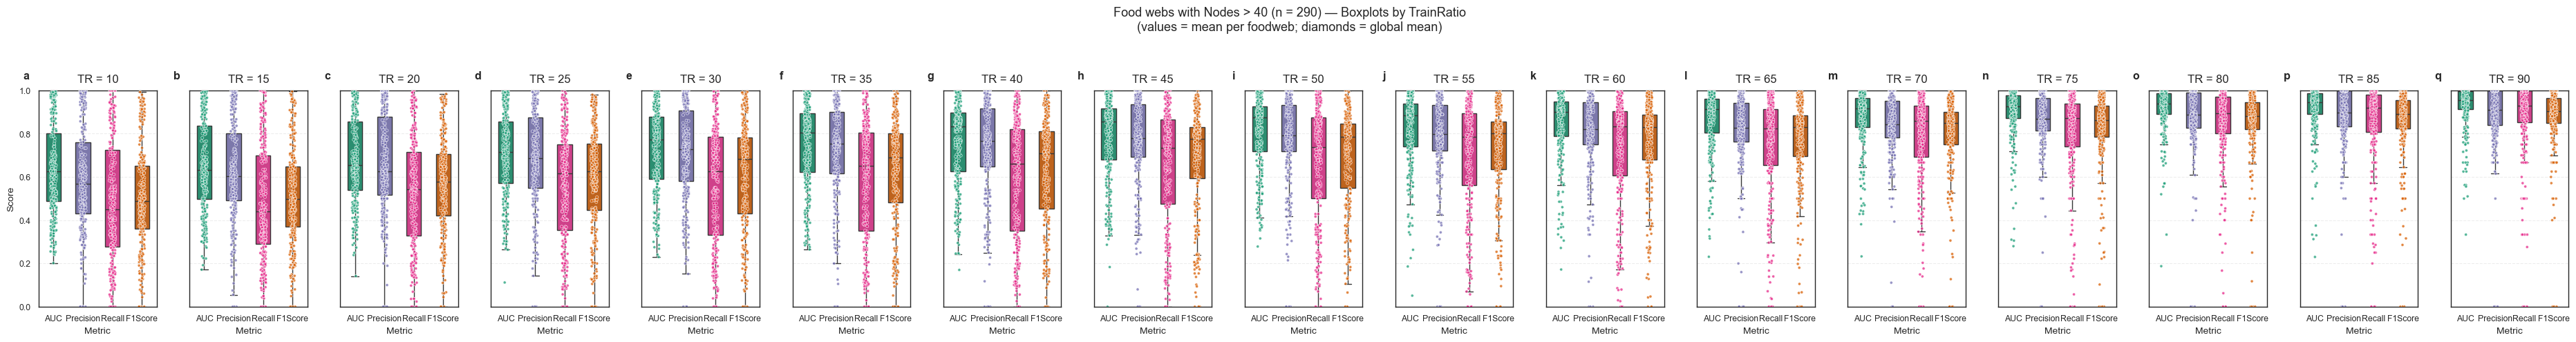

In [1]:
import os, glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# === Configuration ===
RESULTS_DIR = "../../../src/matlab/data/result_sweep_train_ratios_10-90/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None  # disable when using directory
METRICS = ["AUC", "Precision", "Recall", "F1Score"]
MAX_PLOTS = None   # ⬅️ still limits how many CSVs are read; set to None for all 290
NODES_THRESHOLD = 0

# === Utility functions ===
def derive_foodweb_from_filename(path: str) -> str:
    base = os.path.basename(path)
    name, _ = os.path.splitext(base)
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    name = "_".join([p for p in name.split("_") if p])
    return name

def normalize_fw_label(name: str) -> str:
    """
    Make foodweb labels comparable between results CSV and FOODWEB_CSV.
    - strip spaces
    - drop extension (.mat, .csv, etc.)
    - remove common suffixes: _tax_mass, _tax, _mass, _results, _random
    - collapse multiple underscores
    """
    name = str(name).strip()
    name, _ = os.path.splitext(name)   # remove .mat, .csv, etc.
    name = name.replace(" ", "_")
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    parts = [p for p in name.split("_") if p]
    return "_".join(parts)

def load_results(results_dir=None, single_file=None) -> pd.DataFrame:
    paths = []
    if results_dir and os.path.isdir(results_dir):
        paths = sorted(glob.glob(os.path.join(results_dir, "*.csv")))
        if MAX_PLOTS is not None:
            paths = paths[:MAX_PLOTS]
            print(f"[INFO] Limiting to first {len(paths)} CSV files for plotting.")
    if single_file and os.path.isfile(single_file):
        paths.append(single_file)
    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    frames = []
    for p in paths:
        try:
            df = pd.read_csv(p)
        except Exception as e:
            print(f"Skipping {p}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        # Normalize to upper for metrics, keep original for TrainRatio detection
        upper_map = {c: c.upper() for c in df.columns}
        df = df.rename(columns=upper_map)
        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(p)
        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")
    return pd.concat(frames, ignore_index=True)

# === Load (ALL train ratios kept) and preprocess ===
df = load_results(results_dir=RESULTS_DIR, single_file=SINGLE_FILE)

# === Load foodweb metadata and filter Nodes > NODES_THRESHOLD ===
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col_candidates = [c for c in meta.columns if c.lower() == "foodweb"]
nodes_col_candidates = [c for c in meta.columns if c.lower() == "nodes"]
if not fw_col_candidates or not nodes_col_candidates:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

fw_col = fw_col_candidates[0]
nodes_col = nodes_col_candidates[0]

# Normalized keys on BOTH sides
meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

# Foodwebs with Nodes > NODES_THRESHOLD in metadata
allowed_fw_keys = set(
    meta.loc[meta[nodes_col] > NODES_THRESHOLD, "FW_KEY"].unique()
)

print(f"[INFO] Foodwebs with Nodes > {NODES_THRESHOLD} in metadata: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results BEFORE filter: {df['FW_KEY'].nunique()}")

# Filter results
df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()
df.drop(columns=["FW_KEY"], inplace=True)

print(f"[INFO] Foodwebs in results AFTER filter: {df['FOODWEB'].nunique()}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")

# === Normalize TrainRatio into a single 'TRAINRATIO' column (as percentages) ===
tr_candidates = [c for c in df.columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
if not tr_candidates:
    raise ValueError("No TrainRatio column found.")
tr_col = tr_candidates[0]
df["TRAINRATIO"] = pd.to_numeric(df[tr_col], errors="coerce")
if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].astype(int)

# === Auto-detect & sort TrainRatios present in the data ===
TRAIN_RATIOS_DETECTED = sorted(df["TRAINRATIO"].dropna().unique().astype(int).tolist())
if not TRAIN_RATIOS_DETECTED:
    raise ValueError("No valid TrainRatio values were detected.")

# === Prepare long form with TRAINRATIO kept ===
present = [m for m in METRICS if m.upper() in df.columns]
if not present:
    raise ValueError("None of the requested METRICS were found.")
long_frames = []
for m in present:
    mu = m.upper()
    tmp = df[["FOODWEB", "TRAINRATIO", mu]].rename(columns={mu: "Value"})
    tmp["Metric"] = m
    long_frames.append(tmp)
df_long = pd.concat(long_frames, ignore_index=True)

# === Aggregate: mean per FOODWEB, then global mean across foodwebs ===
df_web_means = (
    df_long
    .groupby(["FOODWEB", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

df_mean_overall = (
    df_web_means
    .groupby(["TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
    .rename(columns={"Value": "MeanValue"})
)

n_foodwebs = df_long["FOODWEB"].nunique()

# Custom palette (per metric, consistent across subplots)
metric_colors = {
    "AUC": "#1b9e77", "Precision": "#d95f02",
    "Recall": "#7570b3", "F1Score": "#e7298a",
}
palette = {k: metric_colors.get(k, "#5aa9e6") for k in df_long["Metric"].unique()}
order = list(present)
pal_list = [palette[m] for m in order]

# === Plot: single figure, columns = all detected TrainRatios ===
n_cols = max(1, len(TRAIN_RATIOS_DETECTED))
fig_w = max(7, 2.2 * n_cols)
fig, axes = plt.subplots(1, n_cols, figsize=(fig_w, 5), sharey=True)

if n_cols == 1:
    axes = [axes]

letters_all = [chr(ord('a') + i) for i in range(len(TRAIN_RATIOS_DETECTED))]

for j, tr in enumerate(TRAIN_RATIOS_DETECTED):
    ax = axes[j]
    sub_web = df_web_means[df_web_means["TRAINRATIO"] == tr]
    sub_mean = df_mean_overall[df_mean_overall["TRAINRATIO"] == tr]

    if sub_web.empty:
        ax.set_axis_off()
        ax.text(0.5, 0.5, f"No data\nTR={tr}", ha="center", va="center", fontsize=10)
        continue

    sns.boxplot(
        data=sub_web, x="Metric", y="Value",
        order=order, palette=pal_list,
        hue="Metric",
        width=0.5, showfliers=False,
        ax=ax
    )
    sns.stripplot(
        data=sub_web, x="Metric", y="Value",
        order=order, palette=pal_list,
        hue="Metric",
        dodge=False, jitter=0.10,
        size=3.0, alpha=0.75,
        edgecolor="white", linewidth=0.5,
        ax=ax
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    if j < len(letters_all):
        ax.annotate(
            letters_all[j],
            xy=(0, 1), xycoords="axes fraction",
            xytext=(-10, 10), textcoords="offset points",
            ha="right", va="bottom",
            fontsize="large", fontweight="bold",
            annotation_clip=False
        )

    ax.set_title(f"TR = {tr}", fontsize=12, pad=8)
    ax.set_xlabel("Metric", fontsize=10)
    if j == 0:
        ax.set_ylabel("Score", fontsize=10)
    else:
        ax.set_ylabel("")

    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

fig.suptitle(
    f"Food webs with Nodes > 40 (n = {n_foodwebs}) — Boxplots by TrainRatio\n"
    f"(values = mean per foodweb; diamonds = global mean)",
    y=0.98, fontsize=13
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

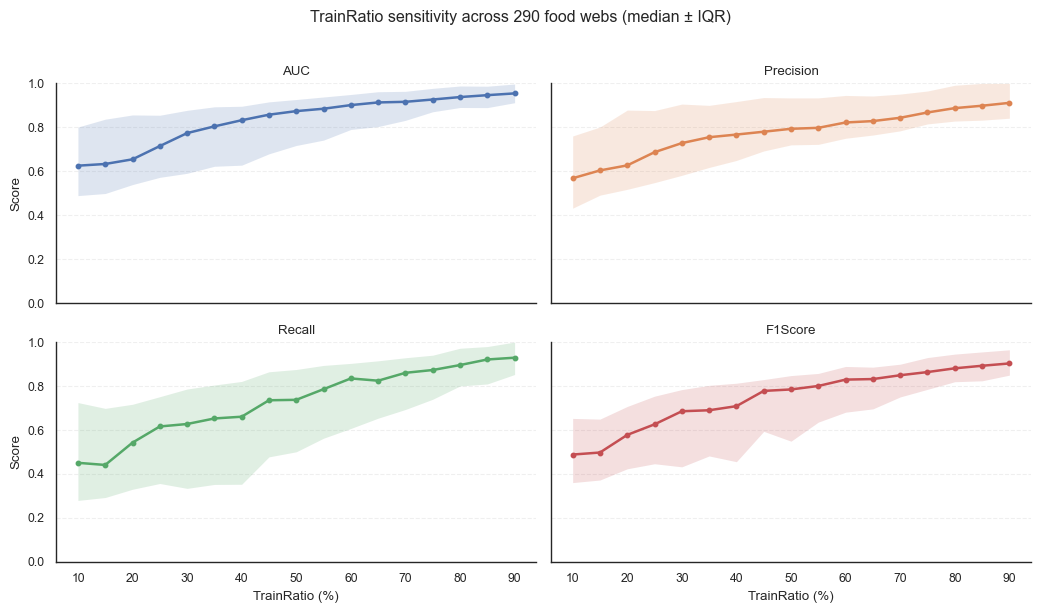

In [2]:
# ============================================================
# Publication-ready TrainRatio figures (3 plots)
# Requires: df_web_means with columns [FOODWEB, TRAINRATIO, Metric, Value]
# ============================================================

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Style (paper) ----
sns.set_context("paper")
sns.set_style("white")

# ---- Output ----
OUT_DIR = "./fig_trainratio_paper"
os.makedirs(OUT_DIR, exist_ok=True)

# ---- Consistent metric colors: seaborn "deep" -> [blue, orange, green, red]
metrics_order = ["AUC", "Precision", "Recall", "F1Score"]
deep4 = sns.color_palette("deep", 4)
metric_colors = {
    "AUC": deep4[0],        # blue
    "Precision": deep4[1],  # orange
    "Recall": deep4[2],     # green
    "F1Score": deep4[3],    # red
}

# Keep only metrics present
metrics_present = [m for m in metrics_order if m in df_web_means["Metric"].unique()]
if not metrics_present:
    raise ValueError("None of the expected metrics were found in df_web_means['Metric'].")

# Ensure TRAINRATIO sorted numeric
df_web_means = df_web_means.copy()
df_web_means["TRAINRATIO"] = pd.to_numeric(df_web_means["TRAINRATIO"], errors="coerce")
df_web_means = df_web_means.dropna(subset=["TRAINRATIO"])
df_web_means["TRAINRATIO"] = df_web_means["TRAINRATIO"].astype(int)

train_ratios = sorted(df_web_means["TRAINRATIO"].unique().tolist())
n_webs = df_web_means["FOODWEB"].nunique()

# ---- Summary across food webs per TrainRatio & metric ----
def q(x, p):
    return x.quantile(p)

summary = (
    df_web_means
    .groupby(["TRAINRATIO", "Metric"])["Value"]
    .agg(
        mean="mean",
        median="median",
        q25=lambda x: q(x, 0.25),
        q75=lambda x: q(x, 0.75),
        std="std",
        n="count",
    )
    .reset_index()
)
summary["iqr"] = summary["q75"] - summary["q25"]

# Helper: show only every 10% label, but keep all points
def set_trainratio_ticks(ax):
    ax.set_xticks(train_ratios)
    ax.set_xticklabels([str(t) if (t % 10 == 0) else "" for t in train_ratios])

# ============================================================
# FIGURE 1: Trajectories (median ± IQR), 2×2
# ============================================================
fig1, axes = plt.subplots(2, 2, figsize=(10.5, 6.2), sharex=True, sharey=True)
axes = axes.ravel()

for ax, metric in zip(axes, metrics_present):
    sub = summary[summary["Metric"] == metric].sort_values("TRAINRATIO")

    x = sub["TRAINRATIO"].to_numpy()
    med = sub["median"].to_numpy()
    q25 = sub["q25"].to_numpy()
    q75 = sub["q75"].to_numpy()

    c = metric_colors[metric]

    ax.fill_between(x, q25, q75, color=c, alpha=0.18, linewidth=0)
    ax.plot(x, med, color=c, marker="o", markersize=3.2, linewidth=1.8)

    ax.set_title(metric)
    ax.set_ylim(0, 1.0)
    ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    sns.despine(ax=ax)

# Hide unused axes if any
for k in range(len(metrics_present), 4):
    axes[k].set_axis_off()

for ax in axes[2:]:
    ax.set_xlabel("TrainRatio (%)")
for ax in axes[::2]:
    ax.set_ylabel("Score")

for ax in axes:
    if ax.has_data():
        set_trainratio_ticks(ax)

fig1.suptitle(
    f"TrainRatio sensitivity across {n_webs} food webs (median ± IQR)",
    y=0.98
)
fig1.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

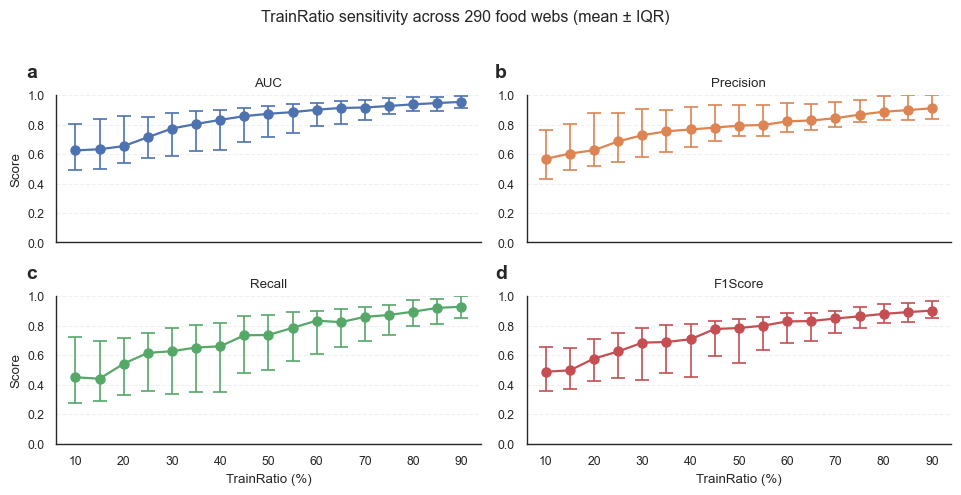

In [17]:
# ============================================================
# FIGURE 1 (new): Trajectories with true error bars (mean ± SE/CI95 or median ± IQR), 2×2
# Adds bold panel letters a–d OUTSIDE each subplot (top-left)
# ============================================================

SHOW_GRID = True   # match your example (clean, no grid)

fig1, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=False)
axes = axes.ravel()

panel_letters = ["a", "b", "c", "d"]

for i, (ax, metric) in enumerate(zip(axes, metrics_present)):
    sub = summary[summary["Metric"] == metric].sort_values("TRAINRATIO").copy()

    x = sub["TRAINRATIO"].to_numpy()
    y = sub["mean"].to_numpy()  # central tendency (mean)

    # asymmetric error bars around the MEDIAN
    y = sub["median"].to_numpy()
    lower = (sub["median"] - sub["q25"]).to_numpy()
    upper = (sub["q75"] - sub["median"]).to_numpy()
    yerr = np.vstack([lower, upper])  # asymmetric

    c = metric_colors[metric]

    ax.errorbar(
        x, y, yerr=yerr,
        fmt="o-", color=c, ecolor=c,
        markersize=6.5, linewidth=1.6,
        elinewidth=1.2, capsize=5, capthick=1.2,
        markerfacecolor=c, markeredgecolor=c
    )

    ax.set_title(metric)
    ax.set_ylim(0, 1.0)

    if SHOW_GRID:
        ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    else:
        ax.grid(False)

    sns.despine(ax=ax)

    # x ticks: keep all positions, label only every 10%
    set_trainratio_ticks(ax)

    # --- Panel letter OUTSIDE the axes (top-left) ---
    if i < len(panel_letters):
        ax.annotate(
            panel_letters[i],
            xy=(0, 1), xycoords="axes fraction",
            xytext=(-14, 10), textcoords="offset points",
            ha="right", va="bottom",
            fontsize=14, fontweight="bold",
            annotation_clip=False
        )

# Hide unused axes if any
for k in range(len(metrics_present), 4):
    axes[k].set_axis_off()

for ax in axes[2:]:
    ax.set_xlabel("TrainRatio (%)")
for ax in axes[::2]:
    ax.set_ylabel("Score")

fig1.suptitle(
    f"TrainRatio sensitivity across {n_webs} food webs (mean ± {ERROR_MODE})",
    y=0.98
)

# Give a bit more left/top margin so outside letters are not cut off
fig1.tight_layout(rect=[0.03, 0, 1, 0.96])

plt.show()

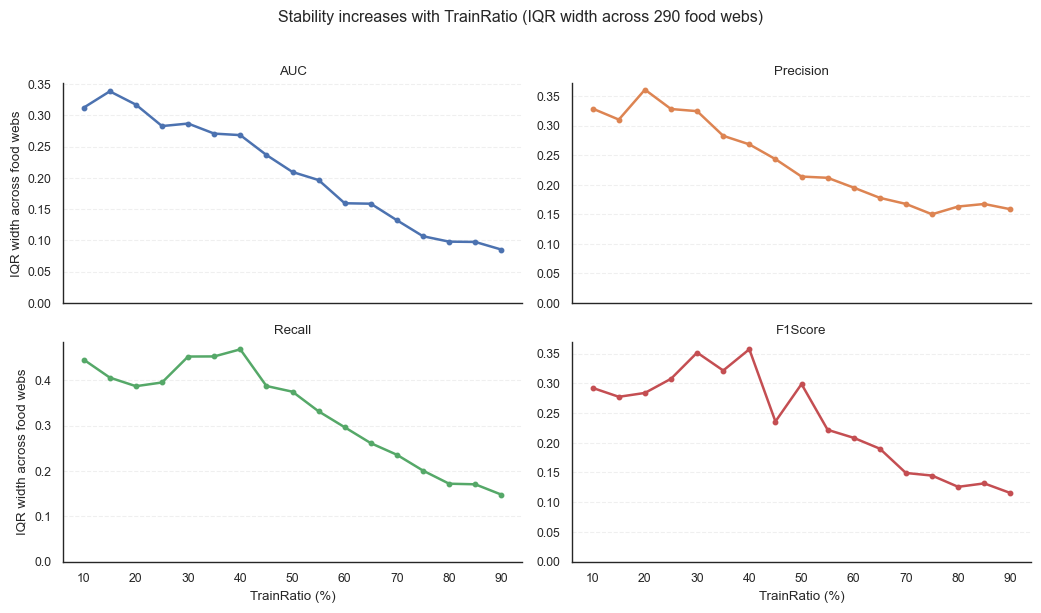

In [ ]:
# ============================================================
# FIGURE 2: Stability contraction (IQR width vs TrainRatio), 2×2
# ============================================================
fig2, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=False)
axes = axes.ravel()

for ax, metric in zip(axes, metrics_present):
    sub = summary[summary["Metric"] == metric].sort_values("TRAINRATIO")

    x = sub["TRAINRATIO"].to_numpy()
    iqr_w = sub["iqr"].to_numpy()

    c = metric_colors[metric]

    ax.plot(x, iqr_w, color=c, marker="o", markersize=3.2, linewidth=1.8)
    ax.set_title(metric)
    ax.set_ylim(bottom=0)
    ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    sns.despine(ax=ax)

# Hide unused axes if any
for k in range(len(metrics_present), 4):
    axes[k].set_axis_off()

for ax in axes[2:]:
    ax.set_xlabel("TrainRatio (%)")
for ax in axes[::2]:
    ax.set_ylabel("IQR width across food webs")

for ax in axes:
    if ax.has_data():
        set_trainratio_ticks(ax)

fig2.suptitle(
    f"Stability increases with TrainRatio (IQR width across {n_webs} food webs)",
    y=0.98
)
fig2.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

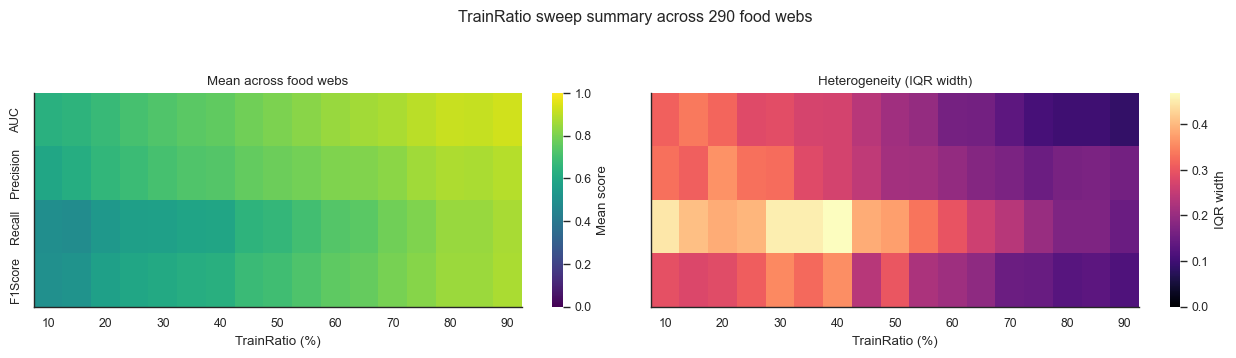

In [5]:
# ============================================================
# FIGURE 3: Heatmaps (mean and IQR), 1×2
# ============================================================
pivot_mean = (
    summary.pivot(index="Metric", columns="TRAINRATIO", values="mean")
    .reindex(metrics_present)
    .reindex(columns=train_ratios)
)
pivot_iqr = (
    summary.pivot(index="Metric", columns="TRAINRATIO", values="iqr")
    .reindex(metrics_present)
    .reindex(columns=train_ratios)
)

fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.8, 3.6), sharey=True)

sns.heatmap(
    pivot_mean,
    ax=ax1,
    vmin=0, vmax=1,
    cmap="viridis",
    cbar_kws={"label": "Mean score"}
)
ax1.set_title("Mean across food webs")
ax1.set_xlabel("TrainRatio (%)")
ax1.set_ylabel("")
ax1.set_xticklabels([str(t) if (t % 10 == 0) else "" for t in train_ratios], rotation=0)

sns.heatmap(
    pivot_iqr,
    ax=ax2,
    vmin=0, vmax=float(np.nanmax(pivot_iqr.values)),
    cmap="magma",
    cbar_kws={"label": "IQR width"}
)
ax2.set_title("Heterogeneity (IQR width)")
ax2.set_xlabel("TrainRatio (%)")
ax2.set_ylabel("")
ax2.set_xticklabels([str(t) if (t % 10 == 0) else "" for t in train_ratios], rotation=0)

# y-labels aligned, clean spines
sns.despine(ax=ax1, left=False, bottom=False)
sns.despine(ax=ax2, left=False, bottom=False)

fig3.suptitle(f"TrainRatio sweep summary across {n_webs} food webs", y=0.98)
fig3.tight_layout(rect=[0, 0, 1, 0.92])

plt.show()

Filtered food webs by size: kept 160 / 290 (>= 40 nodes).


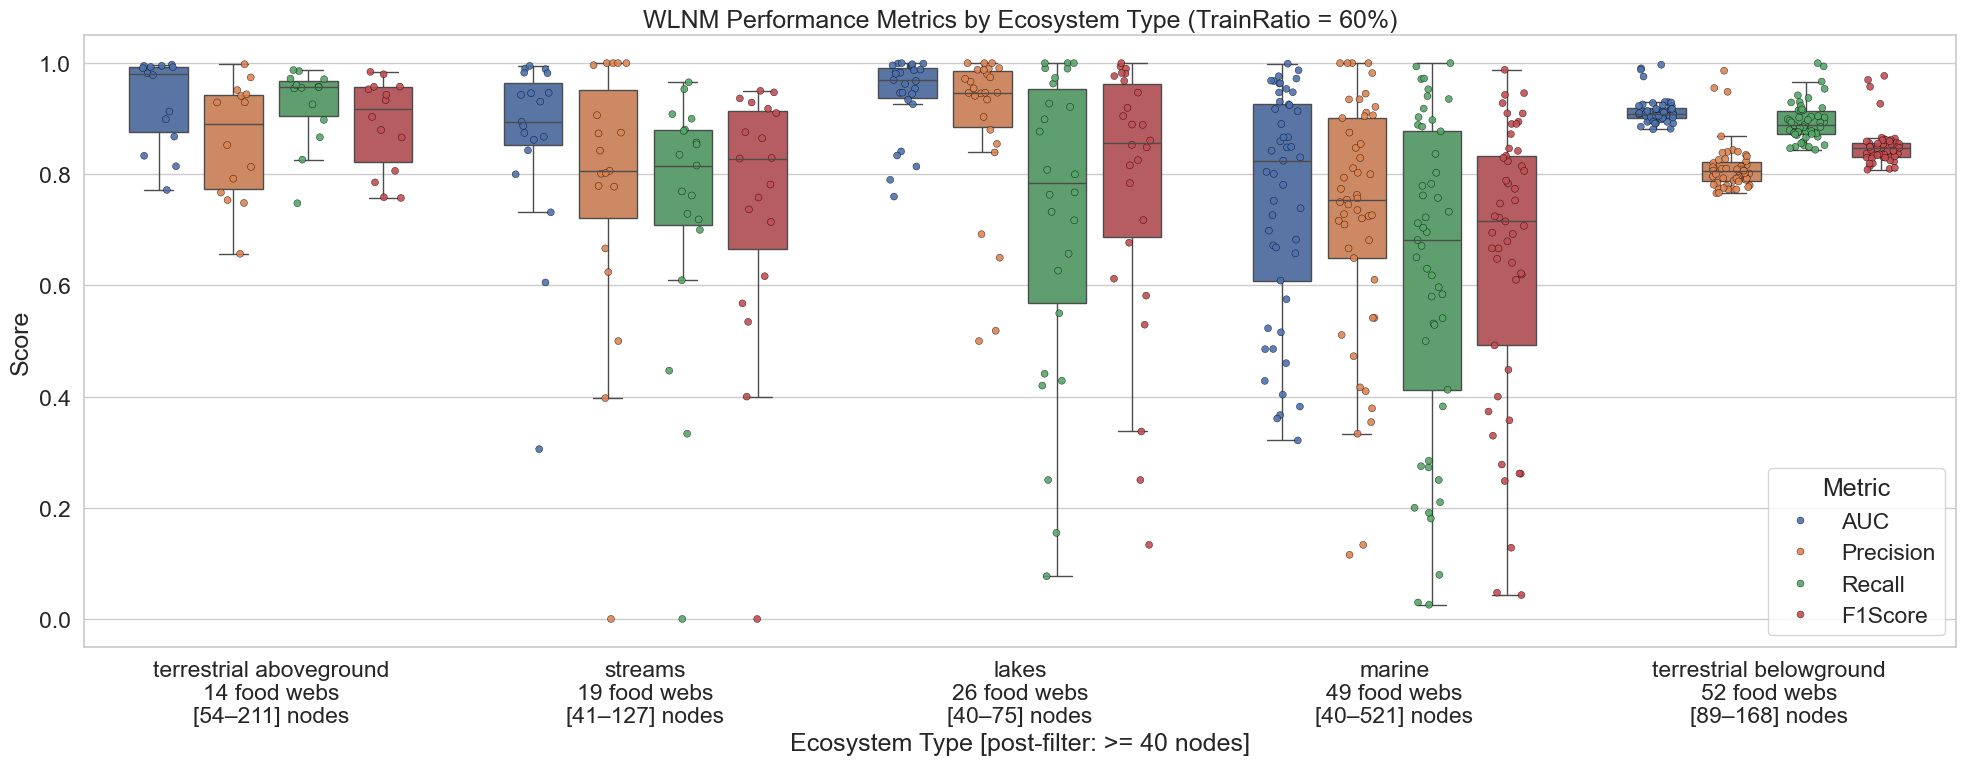

In [1]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Paths ===
results_dir = "../../../src/matlab/data/result_sweep_train_ratios_10-90/prediction_scores_logs"
ecosystem_file = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

METRIC_ORDER = ["AUC", "Precision", "Recall", "F1Score"]

# Take the first 4 colors from seaborn "deep" and map them in the exact order above
deep4 = sns.color_palette("deep", 4)  # [blue, orange, green, red] in seaborn's deep
metric_palette = dict(zip(METRIC_ORDER, deep4))

# === Filtering threshold ===
MIN_NODES = 40  # exclude food webs smaller than this

# === Load ecosystem metadata ===
df_ecosystem = pd.read_csv(ecosystem_file)

# --- Detect a node-count column robustly ---
def _normalize(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

candidates = {
    "n_nodes", "num_nodes", "nodes", "nodecount", "n", "s",
    "species", "numspecies", "numberofspecies", "speciescount"
}
norm_map = {_normalize(c): c for c in df_ecosystem.columns}
node_col = None
for k in candidates:
    if k in norm_map:
        node_col = norm_map[k]
        break

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one (e.g., 'S', 'nodes', 'num_species', 'node_count')."
    )

# === Load result CSVs and stack ===
csv_files = glob.glob(os.path.join(results_dir, "*_results_random.csv"))
dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    filename = os.path.basename(file)
    foodweb = filename.split("_results_")[0]
    df["Foodweb"] = foodweb
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)

# === Merge metrics with ecosystem metadata (ecosystem + node count) ===
meta_cols = ["Foodweb", "EcosystemType", node_col]
df_merged = pd.merge(df_all, df_ecosystem[meta_cols], on="Foodweb", how="left")

# === Apply node-count filter ===
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()
print(f"Filtered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

# === Prepare data for plotting ===
df_plot = df_merged.melt(
    id_vars=["Foodweb", "TrainRatio", "EcosystemType", "Iteration"],
    value_vars=["AUC", "Precision", "Recall", "F1Score"],
    var_name="Metric",
    value_name="Value"
)

# Cast TrainRatio to string for cleaner facet/legend titles if desired
df_plot["TrainRatio"] = df_plot["TrainRatio"].astype(str)

# === Order ecosystems by count (after filtering) ===
ecosystem_order = (
    df_merged[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")
    .size()
    .sort_values()
    .index
    .tolist()
)

# === Build dynamic x-axis labels with counts and node ranges (after filtering) ===
def make_label(group: pd.DataFrame) -> str:
    n_webs = group["Foodweb"].nunique()
    node_min = int(group[node_col].min())
    node_max = int(group[node_col].max())
    name = group.name  # EcosystemType value
    return f"{name}\n{n_webs} food webs\n[{node_min}–{node_max}] nodes"

labels_map = {}
for eco in ecosystem_order:
    grp = df_merged[df_merged["EcosystemType"] == eco]
    if grp.empty:
        continue
    grp.name = eco
    labels_map[eco] = make_label(grp)

custom_labels = [labels_map[eco] for eco in ecosystem_order if eco in labels_map]

from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch

def shrink_seaborn_boxes(ax, factor: float = 0.85) -> None:
    """
    Shrink box widths (and their whisker/cap/median lines) around each box center.
    This creates extra gap between hue boxes inside each category.
    """
    # Seaborn boxes are usually PathPatch objects stored in ax.patches
    box_patches = [p for p in ax.patches if isinstance(p, PathPatch)]
    if not box_patches:
        print("[WARN] No box patches found to shrink.")
        return

    # Whiskers/caps/medians are in ax.lines (typically 6 per box, but can vary by version)
    lines = ax.lines
    n_boxes = len(box_patches)
    lines_per_box = (len(lines) // n_boxes) if (n_boxes > 0 and len(lines) % n_boxes == 0) else 6

    for i, patch in enumerate(box_patches):
        path = patch.get_path()
        verts = path.vertices
        xs = verts[:, 0].copy()
        xmid = (xs.min() + xs.max()) / 2.0

        # shrink the box polygon
        verts[:, 0] = xmid + (xs - xmid) * factor
        patch.set_path(MplPath(verts, path.codes))

        # shrink corresponding lines (whiskers/caps/median) for this box
        start = i * lines_per_box
        end = min(start + lines_per_box, len(lines))
        for line in lines[start:end]:
            xdata = line.get_xdata()
            line.set_xdata(xmid + (xdata - xmid) * factor)

# === Plot ONLY TrainRatio = 60% and overlay points ===
sns.set_theme(style="whitegrid", font_scale=1.5)

# Robust filter to 60% even if stored as "60" or "60.0"
subset = df_plot[df_plot["TrainRatio"].astype(float) == 60.0].copy()
if subset.empty:
    raise RuntimeError("No rows for TrainRatio = 60.0. Check how TrainRatio is stored.")

subset["Metric"] = pd.Categorical(subset["Metric"], categories=METRIC_ORDER, ordered=True)

plt.figure(figsize=(20, 8))

# Boxplot without outliers (keeps view clean for points)
ax = sns.boxplot(
    data=subset,
    x="EcosystemType",
    y="Value",
    hue="Metric",
    hue_order=METRIC_ORDER,
    palette=metric_palette,
    showfliers=False,
    order=ecosystem_order,
)

# Create inner gap between the hue boxplots within each ecosystem
shrink_seaborn_boxes(ax, factor=0.78)  # try 0.75–0.85

# Overlay individual data points (stripplot = jittered dots).
# Use small alpha + linewidth for readability; dodge=True to separate hues.
sns.stripplot(
    data=subset,
    x="EcosystemType",
    y="Value",
    hue="Metric",
    hue_order=METRIC_ORDER,
    palette=metric_palette,
    dodge=True,
    jitter=0.20,
    alpha=0.90,
    linewidth=0.3,
    edgecolor="black",
    order=ecosystem_order,
    zorder=2,
)

# De-duplicate the legend (boxplot + stripplot both add entries)
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))  # keeps last occurrence per label
ax.legend(uniq.values(), uniq.keys(), title="Metric", frameon=True, loc='lower right')

ax.set_title("WLNM Performance Metrics by Ecosystem Type (TrainRatio = 60%)")
ax.set_ylabel("Score")
ax.set_xlabel(f"Ecosystem Type [post-filter: >= {MIN_NODES} nodes]")
ax.set_xticks(range(len(custom_labels)))
ax.set_xticklabels(custom_labels)
plt.tight_layout()
plt.show()

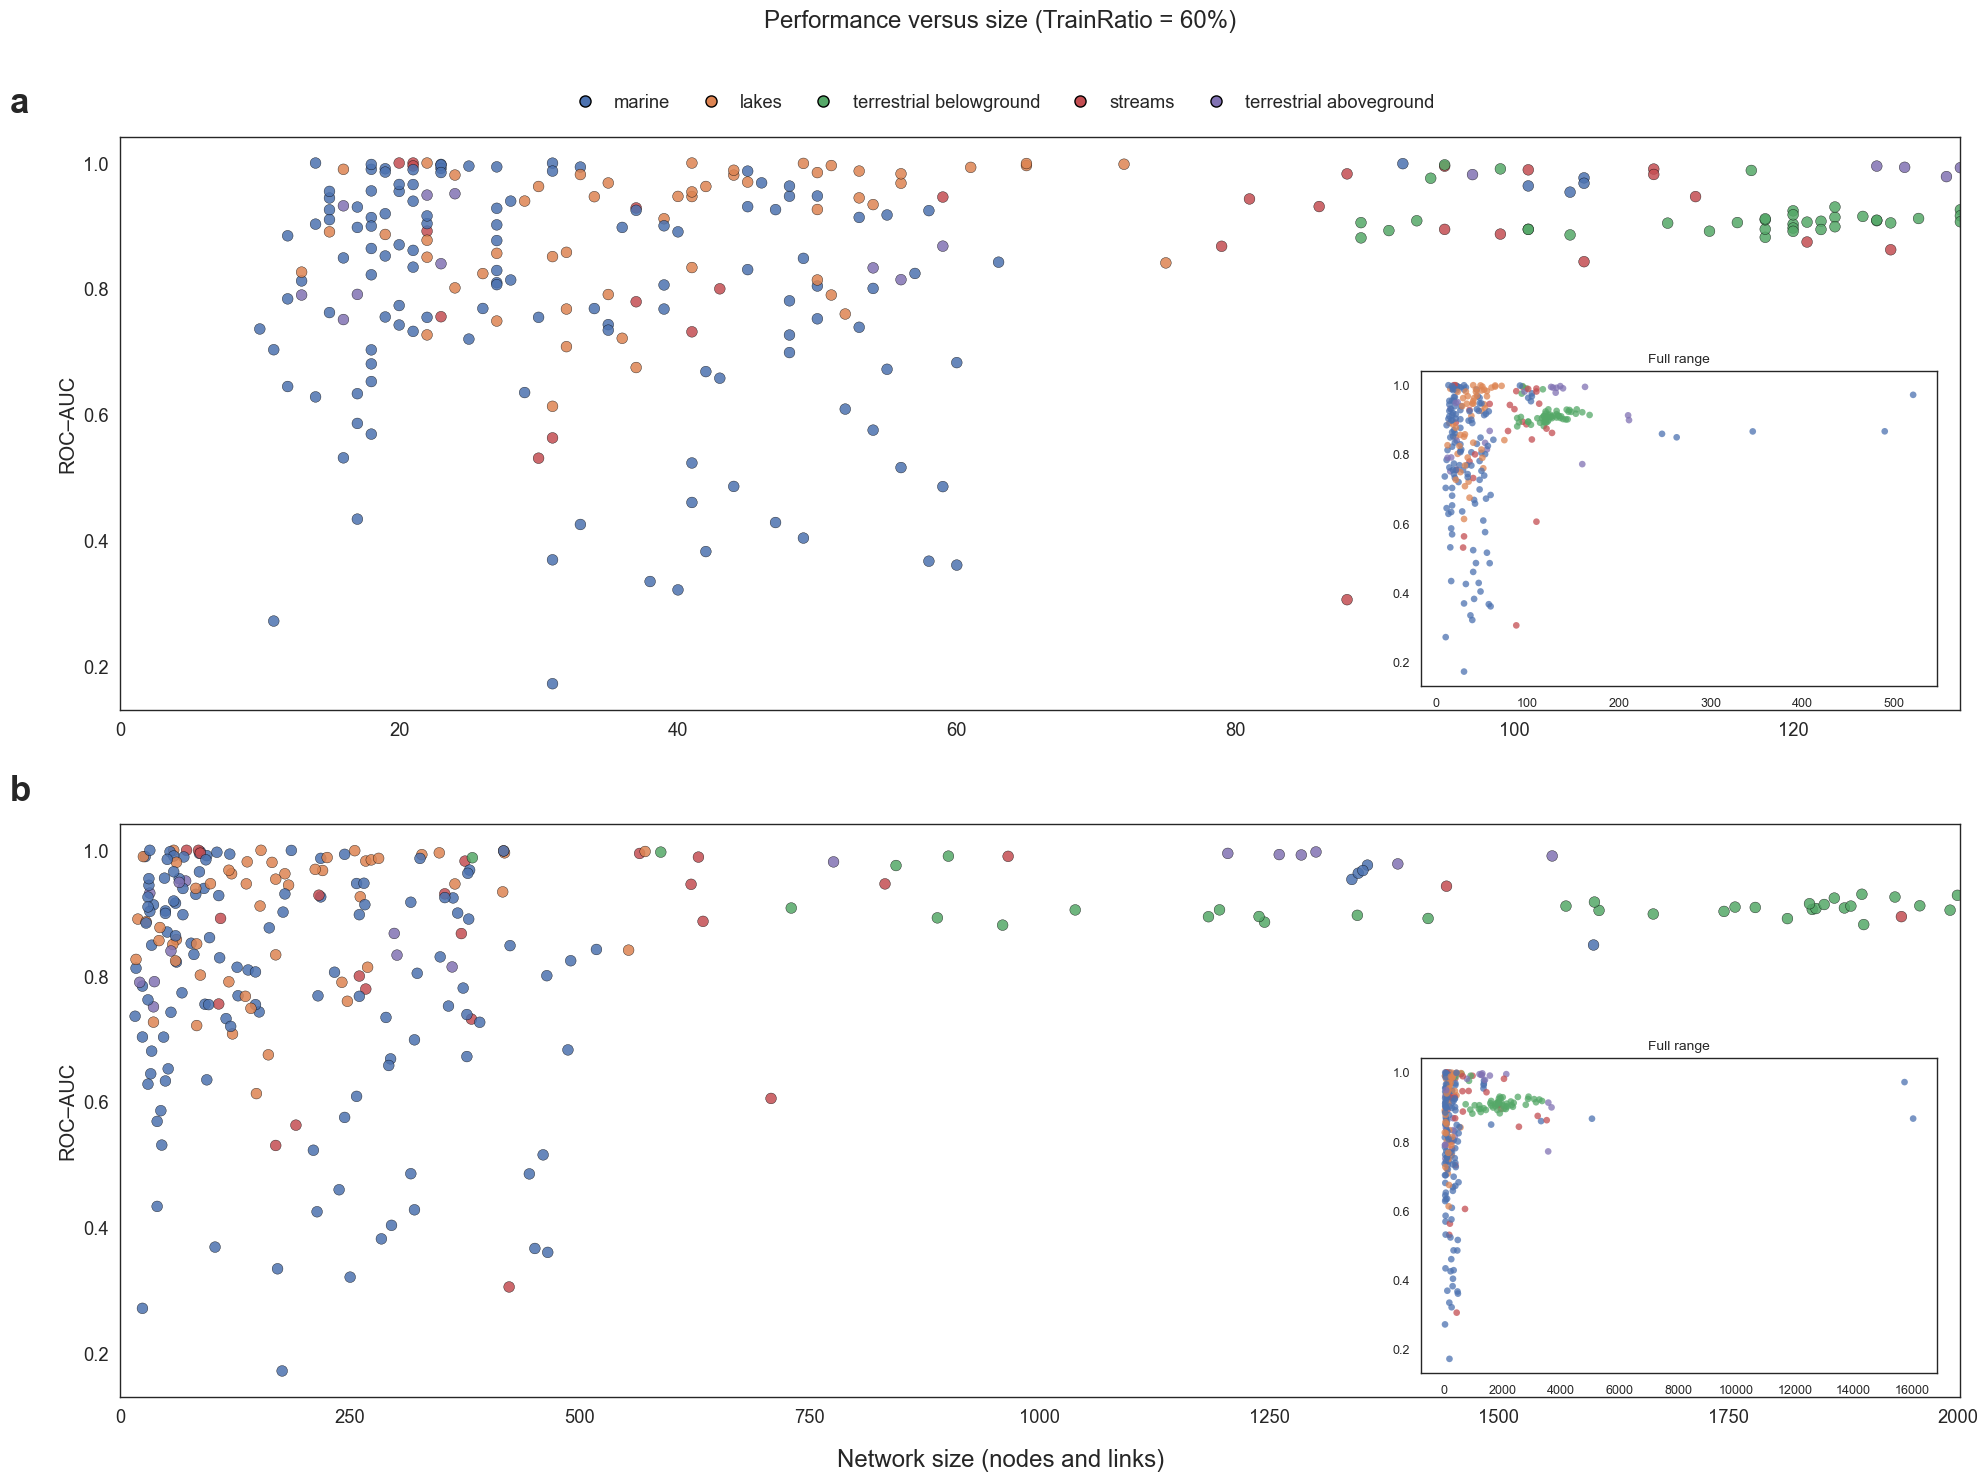

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D

# Explicit column names from df_ecosystem
node_col = "Nodes"
link_col = "Edges"

meta_cols = ["Foodweb", "EcosystemType", node_col, link_col]
df_merged = pd.merge(df_all, df_ecosystem[meta_cols], on="Foodweb", how="left")

MIN_NODES = 0
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()

TARGET_RATIO = 60.0
df_tr = df_merged[df_merged["TrainRatio"].astype(float) == TARGET_RATIO].copy()
if df_tr.empty:
    raise RuntimeError(f"No rows for TrainRatio = {TARGET_RATIO}. Check TrainRatio values.")

df_scatter = (
    df_tr
    .groupby(["Foodweb", "EcosystemType", node_col, link_col], as_index=False)
    .agg(AUC_mean=("AUC", "mean"))
)

# Order ecosystems by frequency (after filtering)
eco_order = df_scatter["EcosystemType"].value_counts().index.tolist()
df_scatter["EcosystemType"] = pd.Categorical(df_scatter["EcosystemType"], categories=eco_order, ordered=True)

# Consistent palette across both panels + insets + legend
eco_colors = sns.color_palette("deep", n_colors=len(eco_order))
eco_palette = dict(zip(eco_order, eco_colors))

sns.set_theme(style="white", context="paper", font_scale=1.5)

fig, axes = plt.subplots(2, 1, figsize=(20, 15), sharex=False)
ax0, ax1 = axes

# ---------- MAIN PLOTS ----------
sns.scatterplot(
    data=df_scatter, x=node_col, y="AUC_mean", hue="EcosystemType",
    palette=eco_palette,
    alpha=0.85, edgecolor="black", linewidth=0.3,
    ax=ax0, legend=False, s=60
)
ax0.set_ylabel("ROC–AUC")
ax0.set_xlabel("")

sns.scatterplot(
    data=df_scatter, x=link_col, y="AUC_mean", hue="EcosystemType",
    palette=eco_palette,
    alpha=0.85, edgecolor="black", linewidth=0.3,
    ax=ax1, legend=False, s=60
)
ax1.set_ylabel("ROC–AUC")
ax1.set_xlabel("")

# ---------- Panel letters ----------
for ax, letter in zip(axes, ["a", "b"]):
    ax.text(
        -0.06, 1.03, letter,
        transform=ax.transAxes,
        fontsize=25, fontweight="bold",
        va="bottom", ha="left",
        clip_on=False,
    )

# ---------- Title + shared x label ----------
fig.suptitle(f"Performance versus size (TrainRatio = {int(TARGET_RATIO)}%)", y=0.985)
fig.supxlabel("Network size (nodes and links)")

# ---------- Legend: figure-level, horizontal, with visible dots ----------
legend_handles = [
    Line2D(
        [0], [0],
        marker="o", linestyle="",
        markersize=8,
        markerfacecolor=eco_palette[name],
        markeredgecolor="black",
        label=name,
    )
    for name in eco_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=len(eco_order),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.6,
)

# ---------- OUTLIER HANDLING ----------
node_xlim = np.nanpercentile(df_scatter[node_col], 90)
link_xlim = np.nanpercentile(df_scatter[link_col], 90)
ax0.set_xlim(left=0, right=node_xlim)
ax1.set_xlim(left=0, right=link_xlim)

# Insets (full range)
ins0 = inset_axes(ax0, width="28%", height="55%", loc="lower right", borderpad=1.3)
sns.scatterplot(
    data=df_scatter, x=node_col, y="AUC_mean", hue="EcosystemType",
    palette=eco_palette,
    alpha=0.75, edgecolor="none", ax=ins0, legend=False
)
ins0.set_title("Full range", fontsize=10)
ins0.set_xlabel("")
ins0.set_ylabel("")
ins0.tick_params(labelsize=9)

ins1 = inset_axes(ax1, width="28%", height="55%", loc="lower right", borderpad=1.3)
sns.scatterplot(
    data=df_scatter, x=link_col, y="AUC_mean", hue="EcosystemType",
    palette=eco_palette,
    alpha=0.75, edgecolor="none", ax=ins1, legend=False
)
ins1.set_title("Full range", fontsize=10)
ins1.set_xlabel("")
ins1.set_ylabel("")
ins1.tick_params(labelsize=9)

# ---------- Layout (replace tight_layout to avoid warning) ----------
# Reserve space at top for title + legend
fig.subplots_adjust(top=0.90, hspace=0.2, left=0.06, right=0.98, bottom=0.06)
plt.show()

[INFO] Foodwebs with Nodes >= 40 in metadata: 160
[INFO] Foodwebs in results AFTER filter: 160


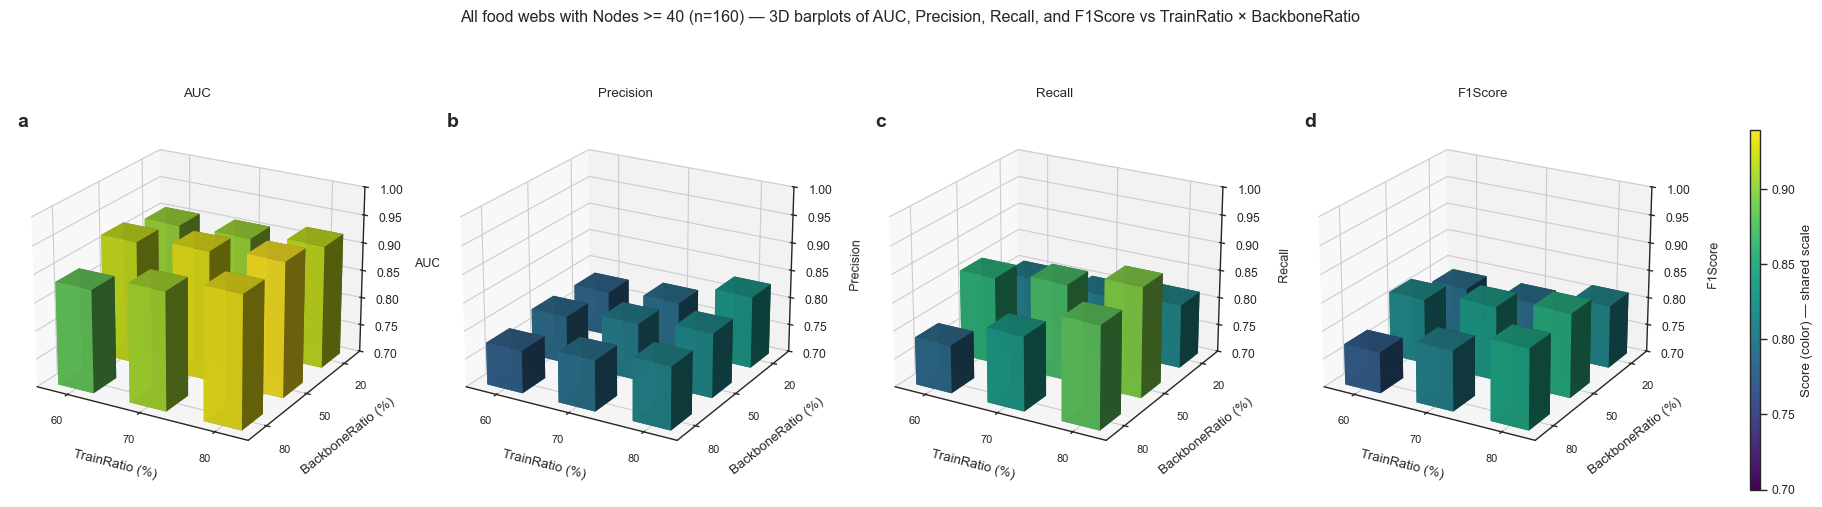

In [5]:
# %% 1x4 3D Barplots over multiple foodweb CSVs (global mean over foodwebs with Nodes > 40)
import os, glob
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import seaborn as sns

# Font setup to avoid Unicode glyph issues
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]
mpl.rcParams["mathtext.fontset"] = "dejavusans"
mpl.rcParams["axes.unicode_minus"] = False

# === Config ===
RESULTS_DIR = (
    "../../../src/matlab/data/"
    "result_sweep_trainRatio_60-80_backboneRatio_20-50-80/"
    "prediction_scores_logs"
)
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
GLOB_PATTERNS = ["*_results_random.csv", "*_results_*.csv", "*_result_*.csv"]
MAX_SHOW = None          # max number of foodweb files to include (None = all)
NODES_THRESHOLD = 40

DX = DY = 0.5        # bar thickness
FLOOR = 0.7          # common floor for all metrics
VIEW_KW = dict(elev=22, azim=-60)  # common 3D view

def normalize_fw_label(name: str) -> str:
    """
    Normaliza etiquetas de foodweb para compararlas entre filenames y FOODWEB_CSV.
    """
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in ["_results_", "_result_", "_results", "_random",
                  "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    parts = [p for p in name.split("_") if p]
    return "_".join(parts)

def pick_column(df: pd.DataFrame, *opts) -> str:
    norm_names = {
        c.lower().replace(" ", "").replace("_", ""): c for c in df.columns
    }
    for o in opts:
        k = o.lower().replace("_", "")
        if k in norm_names:
            return norm_names[k]
    raise KeyError(f"None of {opts} found in columns: {list(df.columns)}")

def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(
        s.astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )

def plot_global_3d(df: pd.DataFrame, title: str):
    """
    1x4 3D barplot (AUC, Precision, Recall, F1Score) vs TrainRatio × BR,
    using all (TR, BR) combinations present in the results.
    """
    # --- Robustly pick TrainRatio and Backbone/NonBackbone ratio columns ---
    train_col = pick_column(df, "TrainRatio", "train_ratio", "trainratio", "train")

    # Accept BackboneRatio (new runs) or NonBackboneRatio (inverse runs)
    rb_col = pick_column(
        df,
        "BackboneRatio", "backbone_ratio", "backboneratio", "backbone",
        "NonBackboneRatio", "nonbackboneratio", "non_backbone_ratio"
    )

    # Detect label for Y axis / title
    rb_is_backbone = rb_col.lower().startswith("backbone")
    rb_label = "BackboneRatio" if rb_is_backbone else "NonBackboneRatio"

    df = df.copy()
    df[train_col] = to_num(df[train_col])
    df[rb_col]    = to_num(df[rb_col])

    # Ensure X/Y are in 0–100 (percent)
    for c in [train_col, rb_col]:
        vals = df[c].dropna()
        if len(vals) and vals.max() <= 1.0:
            df[c] = df[c] * 100

    # NOTE: we NO LONGER drop rows where BR > TR.
    # This allows us to see (TR=60, BR=80) and (TR=70, BR=80) combos.

    # Metric columns with flexible aliases
    metric_aliases = {
        "AUC":       ("AUC", "auc"),
        "Precision": ("Precision", "precision", "prec"),
        "Recall":    ("Recall", "recall", "tpr", "sensitivity"),
        "F1Score":   ("F1Score", "f1score", "f1_score", "f1"),
    }
    metric_cols = {m: pick_column(df, *aliases) for m, aliases in metric_aliases.items()}

    # X/Y grid from data; Y (ratio) descending
    xr = np.sort(df[train_col].dropna().unique())
    yr = np.sort(df[rb_col].dropna().unique())[::-1]

    # Build metric grids (global mean over all included foodwebs)
    grids = {}
    for m, col in metric_cols.items():
        tmp = (
            df.groupby([train_col, rb_col], as_index=False)[col]
              .mean()
              .rename(columns={col: "val"})
        )
        grid = (
            tmp.pivot(index=train_col, columns=rb_col, values="val")
               .reindex(index=xr, columns=yr)
        )
        grids[m] = grid

    # Global normalization for shared colorbar
    vmax_global = max(float(np.nanmax(g.values)) for g in grids.values())
    cmap = cm.viridis
    norm = colors.Normalize(vmin=FLOOR, vmax=vmax_global)

    # === Plot 1x4 ===
    sns.set_theme(style="ticks", context="paper")
    fig = plt.figure(figsize=(20, 6))
    axes = [fig.add_subplot(1, 4, i+1, projection="3d") for i in range(4)]

    for ax, (metric_name, grid) in zip(axes, grids.items()):
        xs, ys, zs, dzh, cols = [], [], [], [], []
        for i, tr in enumerate(xr):
            for j, br in enumerate(yr):
                val = grid.iloc[i, j]
                if np.isnan(val):
                    continue
                height = val - FLOOR
                if height <= 0:
                    continue
                xs.append(i - DX/2)
                ys.append(j - DY/2)
                zs.append(FLOOR)
                dzh.append(height)
                cols.append(cmap(norm(val)))

        ax.bar3d(
            xs, ys, zs,
            DX, DY, dzh,
            shade=True, color=cols,
            edgecolor="none", alpha=0.95
        )

        ax.set_title(metric_name)
        ax.set_xlabel("TrainRatio (%)", labelpad=6)
        ax.set_ylabel(f"{rb_label} (%)", labelpad=6)
        ax.set_zlabel(metric_name, labelpad=8, fontsize=9)

        ax.set_xticks(range(len(xr)))
        ax.set_xticklabels(
            [f"{int(v):d}" if float(v).is_integer() else f"{v:g}" for v in xr],
            fontsize=8
        )
        ax.set_yticks(range(len(yr)))
        ax.set_yticklabels(
            [f"{int(v):d}" if float(v).is_integer() else f"{v:g}" for v in yr],
            fontsize=8
        )

        ax.set_zlim(FLOOR, 1.0)
        ax.view_init(**VIEW_KW)

    # Panel letters
    panel_labels = ["a", "b", "c", "d"]
    for ax, lab in zip(axes, panel_labels):
        ax.text2D(
            0.02, 0.98, lab,
            transform=ax.transAxes,
            ha="left", va="top",
            fontweight="bold", fontsize=14
        )

    # Shared colorbar
    mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array([])
    cbar_ax = fig.add_axes([0.92, 0.18, 0.005, 0.60])
    cb = plt.colorbar(mappable, cax=cbar_ax, aspect=30)
    cb.set_label("Score (color) — shared scale")

    fig.suptitle(
        f"{title} — 3D barplots of AUC, Precision, Recall, and F1Score "
        f"vs TrainRatio × {rb_label}",
        y=0.98
    )

    plt.subplots_adjust(
        left=0.05, right=0.88,
        bottom=0.12, top=0.90,
        wspace=0.15
    )
    plt.show()

# === Discover CSVs ===
all_files = []
for pat in GLOB_PATTERNS:
    all_files.extend(glob.glob(os.path.join(RESULTS_DIR, pat)))
all_files = sorted(set(all_files))
if not all_files:
    raise FileNotFoundError(
        f"No CSVs found in {RESULTS_DIR} with patterns {GLOB_PATTERNS}"
    )

# === Load foodweb metadata & compute allowed keys (Nodes > threshold) ===
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col_candidates = [c for c in meta.columns if c.lower() == "foodweb"]
nodes_col_candidates = [c for c in meta.columns if c.lower() == "nodes"]
if not fw_col_candidates or not nodes_col_candidates:
    raise ValueError(
        "Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV."
    )

fw_col = fw_col_candidates[0]
nodes_col = nodes_col_candidates[0]

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
allowed_fw_keys = set(
    meta.loc[meta[nodes_col] >= NODES_THRESHOLD, "FW_KEY"].unique()
)

print(
    f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD} in metadata: "
    f"{len(allowed_fw_keys)}"
)

# === Read & stack only allowed foodweb CSVs ===
frames = []
included_keys = set()

for fp in all_files:
    if MAX_SHOW is not None and len(included_keys) >= MAX_SHOW:
        print(f"[Info] Reached file limit ({MAX_SHOW}). Skipping remaining files.")
        break

    fw_name_raw = os.path.splitext(os.path.basename(fp))[0]
    fw_key = normalize_fw_label(fw_name_raw)

    if fw_key not in allowed_fw_keys:
        continue

    try:
        df = pd.read_csv(fp)
    except Exception as e:
        print(f"[Skip] {fp}: {e}")
        continue

    df.columns = [c.strip() for c in df.columns]
    df["FOODWEB"] = fw_key
    frames.append(df)
    included_keys.add(fw_key)

if not frames:
    raise ValueError(
        f"No valid CSVs for foodwebs with Nodes >= {NODES_THRESHOLD}."
    )

df_all = pd.concat(frames, ignore_index=True)
n_foodwebs = len(included_keys)
print(f"[INFO] Foodwebs in results AFTER filter: {n_foodwebs}")

# === Single global 3D plot (mean over all filtered foodwebs) ===
global_title = f"All food webs with Nodes >= {NODES_THRESHOLD} (n={n_foodwebs})"
plot_global_3d(df_all, global_title)